In [31]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-09 11:00:23.371981


# Global analysis
* UMAPs - single and double positive cells
* Barcharts for each label type for scANVI and Seurat

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [37]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [38]:
#plt.rcParams['figure.figsize'] = (3, 3)
#plt.rcParams['figure.dpi'] = 150
#warnings.simplefilter(action='ignore', category=FutureWarning)

### Setup

In [39]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_03/03c_thresholds"

In [40]:
base_dir = Path("/home/workspace/projects/drg")
input_dir = base_dir / "data/h5ad/export_03/03c_thresholds"

adata_path = input_dir / "adata-labeled.h5ad"

In [41]:
adata = sc.read_h5ad(adata_path)

In [45]:
# Boolean masks
egfp = adata.obs["EGFP_Seq1_hi"].astype(bool)
dtom = adata.obs["dTomato_Seq2_hi"].astype(bool)
dual = adata.obs["EGFP_dTomato_dual_hi"].astype(bool)

egfp_single = egfp & ~dtom
dtom_single = dtom & ~egfp
dual_pos    = dual

# Build a small table
df = pd.DataFrame({
    "barcode": adata.obs.index,
    "seurat_label": adata.obs["seurat_labels"],
    "scanvi_label": adata.obs["scanvi_labels"],
    "sample_id": adata.obs["sample_id"],
    "confidence": adata.obs["confidence"],
    "EGFP_single": egfp_single.values,
    "dTom_single": dtom_single.values,
    "Dual_positive": dual_pos.values,
})

# Summary
df[df["Dual_positive"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
apeeemip-1,apeeemip-1,Vascular_endothelial_1,Vascular_endothelial_1,Middle
bpoikicj-1,bpoikicj-1,CGRP-Gamma,CGRP-Gamma,High
cbhmmeof-1,cbhmmeof-1,CGRP-Gamma,CGRP-Gamma,High
bmjgagok-1,bmjgagok-1,CGRP-Gamma,CGRP-Gamma,High
ijnggkoc-1,ijnggkoc-1,CGRP-Gamma,CGRP-Gamma,High
llknggjo-1,llknggjo-1,CGRP-Gamma,CGRP-Gamma,High
llmfnafp-1,llmfnafp-1,CGRP-Gamma,CGRP-Gamma,High
llmgffik-1,llmgffik-1,CGRP-Gamma,CGRP-Gamma,High
jjmnhibg-1,jjmnhibg-1,CGRP-Gamma,CGRP-Gamma,NaN
jkabbhfm-1,jkabbhfm-1,CGRP-Gamma,CGRP-Gamma,NaN


In [49]:
import pandas as pd

# Boolean masks
egfp = adata.obs["EGFP_Seq1_hi"].astype(bool)
dtom = adata.obs["dTomato_Seq2_hi"].astype(bool)
dual = adata.obs["EGFP_dTomato_dual_hi"].astype(bool)

egfp_single = egfp & ~dtom
dtom_single = dtom & ~egfp
dual_pos    = dual

# Build dataframe
df = pd.DataFrame({
    "barcode": adata.obs.index,
    "sample_id": adata.obs["sample_id"],
    "seurat_label": adata.obs["seurat_labels"],
    "scanvi_label": adata.obs["scanvi_labels"],
    "confidence": adata.obs["confidence"],
    "EGFP_single": egfp_single.values,
    "dTom_single": dtom_single.values,
    "Dual_positive": dual_pos.values,
})

# Masks
dual_mask = df["Dual_positive"]
conf_mask = df["confidence"].notna()

# ------------------------------
# 1. Dual-positive WITH confidence
# ------------------------------
dual_with_conf = df[dual_mask & conf_mask]

# ------------------------------
# 2. Dual-positive WITHOUT confidence
# ------------------------------
dual_without_conf = df[dual_mask & ~conf_mask]

# ------------------------------
# 3. Confidence entries that ARE dual-positive
#    (same as #1)
# ------------------------------
conf_and_dual = dual_with_conf

# ------------------------------
# 4. Confidence entries that are NOT dual-positive
# ------------------------------
conf_not_dual = df[conf_mask & ~dual_mask]

In [50]:
# Dual positive, computational ID
print("=== Dual-positive WITH confidence ===")
print(dual_with_conf[["barcode", "sample_id", "seurat_label", "scanvi_label", "confidence"]])
print(f"Total: {len(dual_with_conf)}\n")

print("=== Dual-positive WITHOUT confidence ===")
print(dual_without_conf[["barcode", "sample_id", "seurat_label", "scanvi_label"]])
print(f"Total: {len(dual_without_conf)}\n")

=== Dual-positive WITH confidence ===
               barcode sample_id            seurat_label  \
apeeemip-1  apeeemip-1  TMA00304  Vascular_endothelial_1   
bpoikicj-1  bpoikicj-1  TMA00304              CGRP-Gamma   
cbhmmeof-1  cbhmmeof-1  TMA00304              CGRP-Gamma   
bmjgagok-1  bmjgagok-1  TMA00306              CGRP-Gamma   
ijnggkoc-1  ijnggkoc-1  TMA00306              CGRP-Gamma   
llknggjo-1  llknggjo-1  TMA00306              CGRP-Gamma   
llmfnafp-1  llmfnafp-1  TMA00306              CGRP-Gamma   
llmgffik-1  llmgffik-1  TMA00306              CGRP-Gamma   
aefmnmje-1  aefmnmje-1  TMA00311              CGRP-Gamma   
akcoadof-1  akcoadof-1  TMA00305              CGRP-Gamma   
bgmdeeeb-1  bgmdeeeb-1  TMA00305              CGRP-Gamma   
hjjgalia-1  hjjgalia-1  TMA00305              CGRP-Gamma   
hjjkhdhk-1  hjjkhdhk-1  TMA00305                CGRP-Eta   
mnhcfodp-1  mnhcfodp-1  TMA00305              CGRP-Gamma   
aapmhgin-1  aapmhgin-1  TMA00307              CGRP-Gamma   
eb

In [51]:
# Dual positive, manual ID
print("=== Confidence entries that ARE Dual-positive ===")
print(conf_and_dual[["barcode", "sample_id", "seurat_label", "scanvi_label", "confidence"]])
print(f"Total: {len(conf_and_dual)}\n")

print("=== Manual annotations that are NOT Dual-positive ===")
print(conf_not_dual[["barcode", "sample_id", "seurat_label", "scanvi_label", "confidence"]])
print(f"Total: {len(conf_not_dual)}")

=== Confidence entries that ARE Dual-positive ===
               barcode sample_id            seurat_label  \
apeeemip-1  apeeemip-1  TMA00304  Vascular_endothelial_1   
bpoikicj-1  bpoikicj-1  TMA00304              CGRP-Gamma   
cbhmmeof-1  cbhmmeof-1  TMA00304              CGRP-Gamma   
bmjgagok-1  bmjgagok-1  TMA00306              CGRP-Gamma   
ijnggkoc-1  ijnggkoc-1  TMA00306              CGRP-Gamma   
llknggjo-1  llknggjo-1  TMA00306              CGRP-Gamma   
llmfnafp-1  llmfnafp-1  TMA00306              CGRP-Gamma   
llmgffik-1  llmgffik-1  TMA00306              CGRP-Gamma   
aefmnmje-1  aefmnmje-1  TMA00311              CGRP-Gamma   
akcoadof-1  akcoadof-1  TMA00305              CGRP-Gamma   
bgmdeeeb-1  bgmdeeeb-1  TMA00305              CGRP-Gamma   
hjjgalia-1  hjjgalia-1  TMA00305              CGRP-Gamma   
hjjkhdhk-1  hjjkhdhk-1  TMA00305                CGRP-Eta   
mnhcfodp-1  mnhcfodp-1  TMA00305              CGRP-Gamma   
aapmhgin-1  aapmhgin-1  TMA00307              CGRP

# UMAP

In [11]:
# Extract masks
egfp_hi = adata.obs["EGFP_Seq1_hi"].values
td_hi   = adata.obs["dTomato_Seq2_hi"].values
dual_hi = adata.obs["EGFP_dTomato_dual_hi"].values

egfp_only = egfp_hi & ~td_hi
td_only   = td_hi   & ~egfp_hi

In [13]:
summary = pd.DataFrame({
    "EGFP_only": [egfp_only.sum()],
    "dTomato_only": [td_only.sum()],
    "dual_high": [dual_hi.sum()],
    "any_positive": [(egfp_hi | td_hi).sum()]
})
summary

,EGFP_only,dTomato_only,dual_high,any_positive
0,58,117,23,198


In [ ]:
# Get umap coordinates and indices
umap = adata.obsm["X_umap"]

egfp_idx = np.where(egfp_only)[0]
td_idx   = np.where(td_only)[0]
dual_idx = np.where(dual_hi)[0]

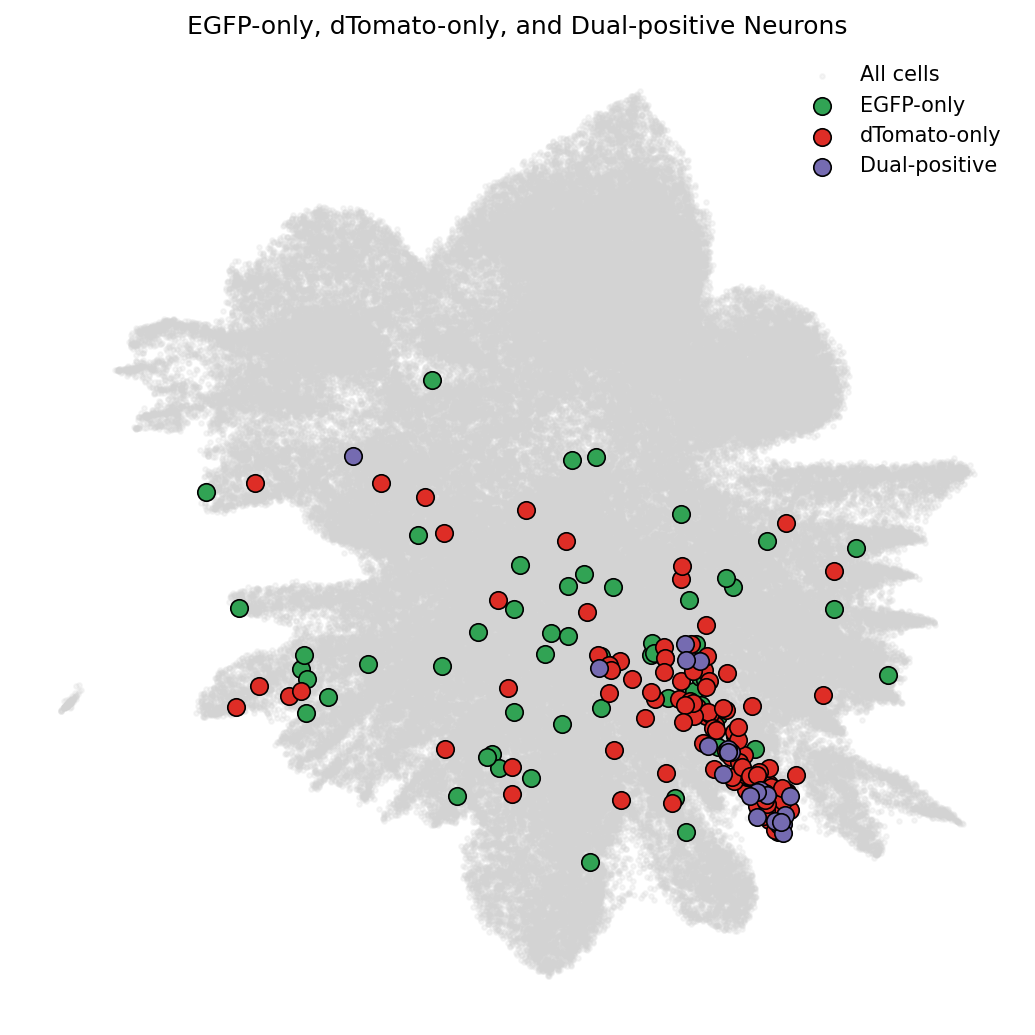

In [12]:
# plot
plt.figure(figsize=(7, 7), dpi=150)

# Background
plt.scatter(
    umap[:, 0], umap[:, 1],
    s=5, c="lightgray", alpha=0.20,
    label="All cells"
)

# EGFP-only (green)
plt.scatter(
    umap[egfp_idx, 0], umap[egfp_idx, 1],
    s=70, c="#31a354",
    edgecolors="black", linewidths=0.8,
    label="EGFP-only"
)

# dTomato-only (red)
plt.scatter(
    umap[td_idx, 0], umap[td_idx, 1],
    s=70, c="#de2d26",
    edgecolors="black", linewidths=0.8,
    label="dTomato-only"
)

# Dual positive (purple)
plt.scatter(
    umap[dual_idx, 0], umap[dual_idx, 1],
    s=70, c="#756bb1",
    edgecolors="black", linewidths=0.8,
    label="Dual-positive"
)

plt.title("EGFP-only, dTomato-only, and Dual-positive Neurons")
plt.xticks([]); plt.yticks([])
sns.despine(left=True, bottom=True)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

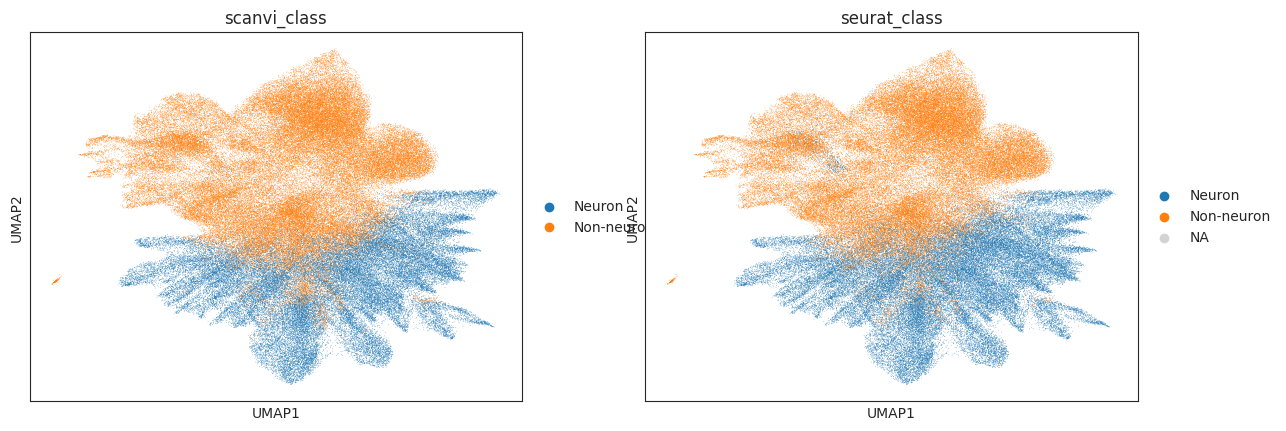

In [36]:
sc.pl.umap(adata, color = ['scanvi_class', 'seurat_class'])

# Single and double-positive distributions

## Bar plots

In [14]:
def plot_bar_from_labels(
    data,
    label_col,
    title,
    figsize=(6,4),
    horizontal=False,
    color="steelblue"
):
    counts = data[label_col].value_counts()

    # Use seaborn style that *keeps* ticks
    sns.set_style("ticks")

    fig, ax = plt.subplots(figsize=figsize)

    # ---- Plot ----
    if horizontal:
        sns.barplot(
            y=counts.index,
            x=counts.values,
            color=color,
            edgecolor="black",
            ax=ax
        )
        ax.set_xlabel("Count", fontsize=10)
        ax.set_ylabel(label_col, fontsize=10)

        # integer ticks
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    else:
        sns.barplot(
            x=counts.index,
            y=counts.values,
            color=color,
            edgecolor="black",
            ax=ax
        )
        ax.set_ylabel("Count", fontsize=10)
        ax.set_xlabel(label_col, fontsize=10)
        plt.xticks(rotation=45, ha="right", fontsize=9)
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    # ---- Make tick marks visible and nice ----
    ax.tick_params(
        axis="both",
        which="both",
        length=4,
        width=1,
        direction="out",
        labelsize=9
    )

    # Keep only bottom & left spines (clean aesthetic)
    sns.despine(ax=ax)

    ax.set_title(title, fontsize=12)
    plt.tight_layout()
    plt.show()

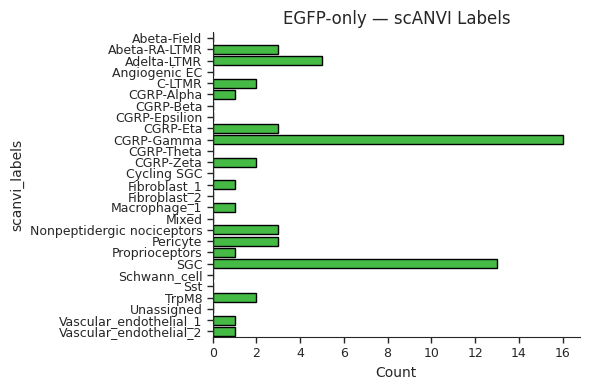

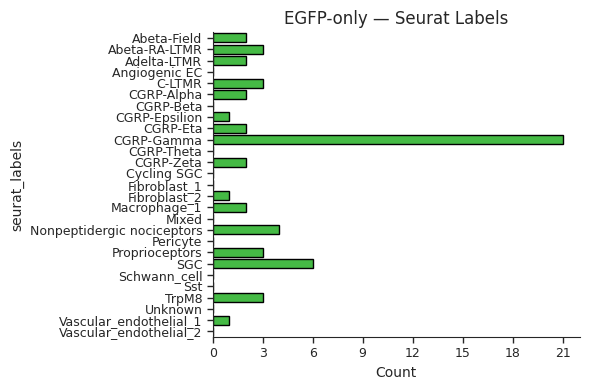

In [15]:
# EGFP-only — scANVI
plot_bar_from_labels(
    adata.obs[egfp_only],
    label_col="scanvi_labels",
    title="EGFP-only — scANVI Labels",
    horizontal=True,
    color="limegreen"
)

# EGFP-only — Seurat
plot_bar_from_labels(
    adata.obs[egfp_only],
    label_col="seurat_labels",
    title="EGFP-only — Seurat Labels",
    horizontal=True,
    color="limegreen"
)

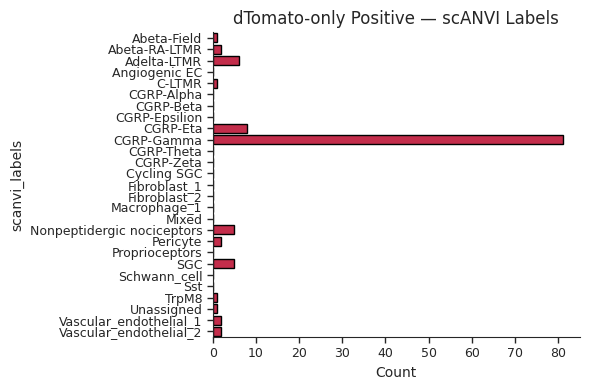

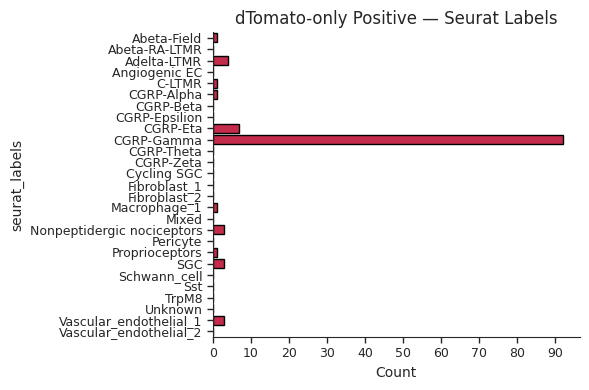

In [16]:
# dTomato-only: scANVI labels (bright red)
plot_bar_from_labels(
    adata.obs[td_only],
    "scanvi_labels",
    "dTomato-only Positive — scANVI Labels",
    horizontal=True,
    color="crimson"
)

# dTomato-only: Seurat labels (bright red)
plot_bar_from_labels(
    adata.obs[td_only],
    "seurat_labels",
    "dTomato-only Positive — Seurat Labels",
    horizontal=True,
    color="crimson"
)

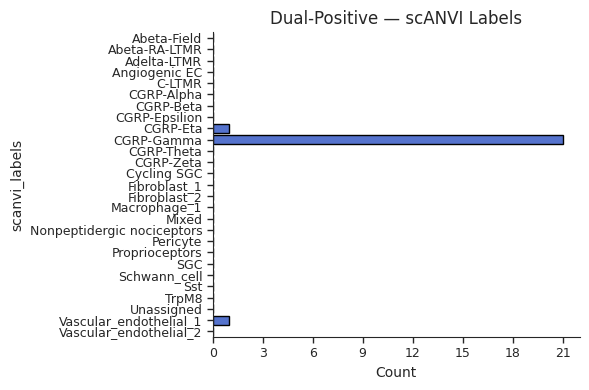

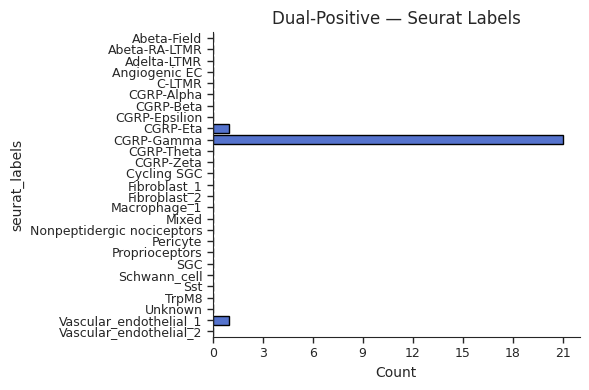

In [17]:
# Dual-positive: scANVI labels (royalblue)
plot_bar_from_labels(
    adata.obs[dual_hi],
    "scanvi_labels",
    "Dual-Positive — scANVI Labels",
    horizontal=True,
    color="royalblue"
)

# Dual-positive: Seurat labels (royalblue)
plot_bar_from_labels(
    adata.obs[dual_hi],
    "seurat_labels",
    "Dual-Positive — Seurat Labels",
    horizontal=True,
    color="royalblue"
)